In [1]:
%matplotlib widget

# Piecewise 1D inversion of 3D channel

In [2]:
import numpy as np
import pygimli as pg
import empymod as ep
import sys
import matplotlib.pyplot as plt
sys.path.insert(1, 'src')

from FDEM1D import FDEM1DModelling_nosort

from showStitched import showStitchedModels

from Plot import grid

# Load data

In [3]:
print('Using files:')
print('data/data_3DChannel_nosort.npy')
print()

# model parameters [h_1, sigma_1, sigma_2]

data = np.load('data/data_3DChannel_nosort.npy')

Using files:
data/data_3DChannel_nosort.npy



In [4]:
# Load true model

model_true = np.load('models/model_3DChannel.npy')

In [5]:
npos = len(data) # number of 1D models
nlay = 2 # number of layers

In [6]:
fop = FDEM1DModelling_nosort(nlay=nlay)

transThk = pg.trans.TransLogLU(0.1,5)
transSig = pg.trans.TransLogLU(1/1000,200/1000)

fop.region(0).setTransModel(transThk)
fop.region(1).setTransModel(transSig)

# Perform inversion in each position

startModel = np.array([3, 0.1, 0.1]) # initial model

model_inv = []
response = []

# Invert

In [7]:
for pos in range(npos):
    dat = data[pos]
    rel_err = np.ones_like(dat)*1e-3 
    inv = pg.Inversion(fop)
    model_inv.append(inv.run(dataVals=dat, errorVals=rel_err, startModel=startModel, verbose=False, lam=0 ))
    response.append(inv.response)

In [8]:
m = np.array(model_inv)

m = m.reshape(40,40,3)

In [9]:
model_inv_grid = []

model_true_grid = []

for i in range(m.shape[0]):
    model_inv_grid.append(grid(m[:,i,:], depthmax=6))

for i in range(model_true.shape[1]):
    model_true_grid.append(grid(model_true[i,:,:], depthmax=6))

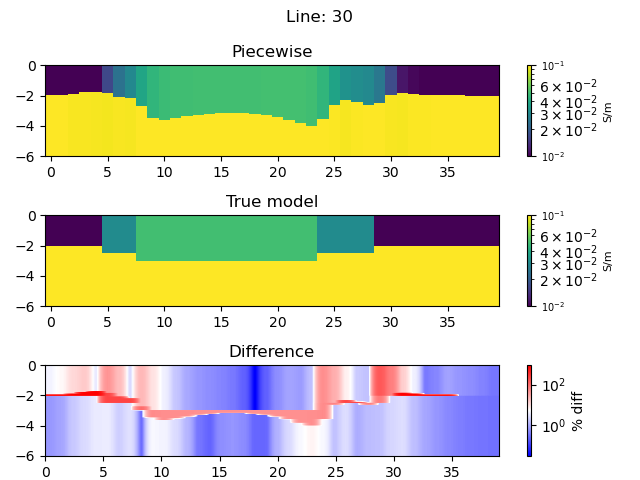

In [17]:
fig, ax = plt.subplots(3)

l =30

showStitchedModels(m[:,l,:], zMax= 6, cMin=10/1000, cMax=100/1000, ax=ax[0], label='S/m')
ax[0].set_title('Piecewise')
showStitchedModels(model_true[l,:,:], zMax= 6, cMin=10/1000, cMax=100/1000, ax=ax[1], label='S/m')
ax[1].set_title('True model')

c2 = ax[2].imshow(np.abs((model_inv_grid[l].T - model_true_grid[l].T)/model_true_grid[l].T)*100, extent=([0, 39,-6,0]), cmap='bwr', aspect=1.3, norm='log')
fig.colorbar(c2, ax=ax[2], label='% diff')
ax[2].set_title('Difference')

fig.suptitle('Line: '+str( l))

plt.tight_layout()

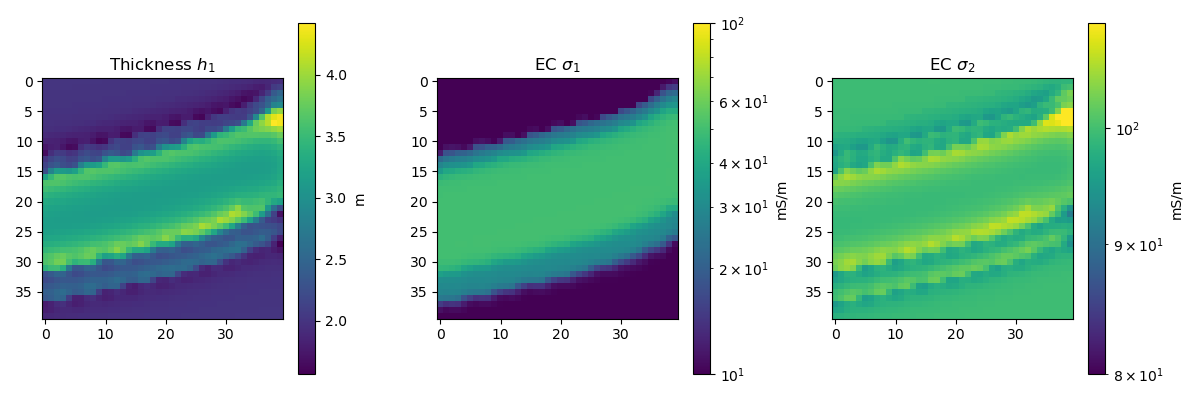

In [11]:
fig, ax = plt.subplots(1,3, figsize=(12,4))

c1 = ax[0].imshow(m[:,:,0])
fig.colorbar(c1, ax=ax[0], label='m',)
ax[0].set_title('Thickness $h_1$')

c2 = ax[1].imshow(m[:,:,1]*1000, vmin =10, vmax=100, norm='log')
fig.colorbar(c2, ax=ax[1], label='mS/m')
ax[1].set_title('EC $\sigma_1$')

c3 = ax[2].imshow(m[:,:,2]*1000, vmin =80, vmax=110, norm='log')
fig.colorbar(c3, ax=ax[2], label='mS/m')
ax[2].set_title('EC $\sigma_2$')

plt.tight_layout()

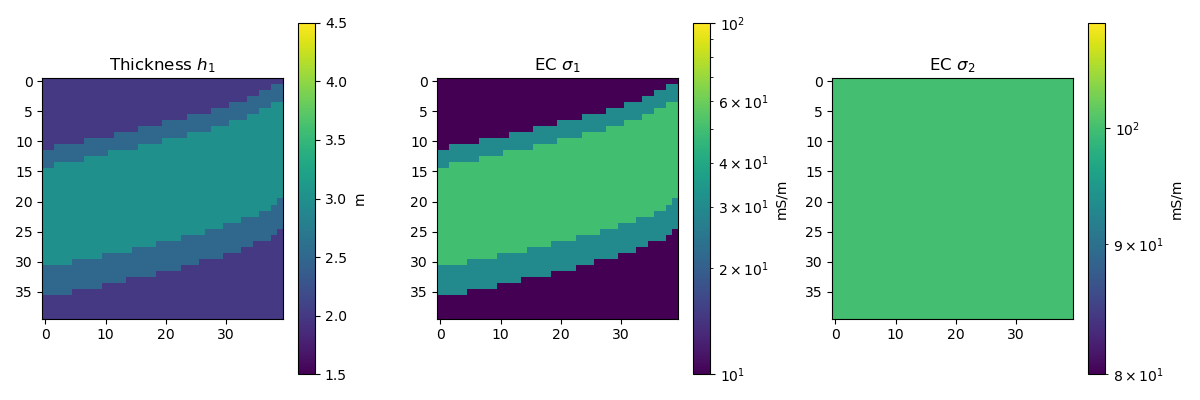

In [12]:
fig, ax = plt.subplots(1,3, figsize=(12,4))

c1 = ax[0].imshow(model_true[:,:,0].T, vmin=1.5, vmax=4.5)
fig.colorbar(c1, ax=ax[0], label='m')
ax[0].set_title('Thickness $h_1$')

c2 = ax[1].imshow(model_true[:,:,1].T*1000, vmin =10, vmax=100, norm='log')
fig.colorbar(c2, ax=ax[1], label='mS/m')
ax[1].set_title('EC $\sigma_1$')

c3 = ax[2].imshow(model_true[:,:,2].T*1000, vmin =80, vmax=110, norm='log')
fig.colorbar(c3, ax=ax[2], label='mS/m')
ax[2].set_title('EC $\sigma_2$')

plt.tight_layout()

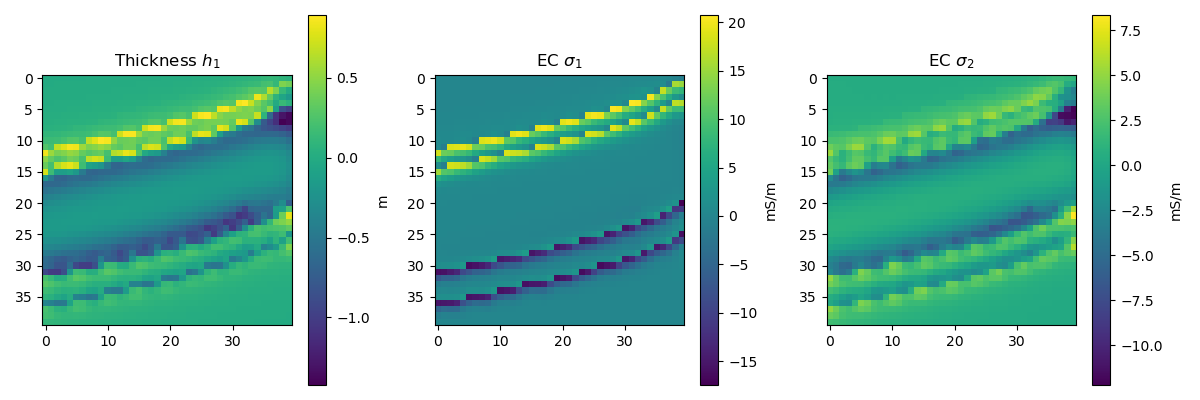

In [13]:
fig, ax = plt.subplots(1,3, figsize=(12,4))

c1 = ax[0].imshow(model_true[:,:,0].T-m[:,:,0])
fig.colorbar(c1, ax=ax[0], label='m')
ax[0].set_title('Thickness $h_1$')

c2 = ax[1].imshow(model_true[:,:,1].T*1000-m[:,:,1]*1000)
fig.colorbar(c2, ax=ax[1], label='mS/m')
ax[1].set_title('EC $\sigma_1$')

c3 = ax[2].imshow(model_true[:,:,2].T*1000-m[:,:,2]*1000)
fig.colorbar(c3, ax=ax[2], label='mS/m')
ax[2].set_title('EC $\sigma_2$')

plt.tight_layout()

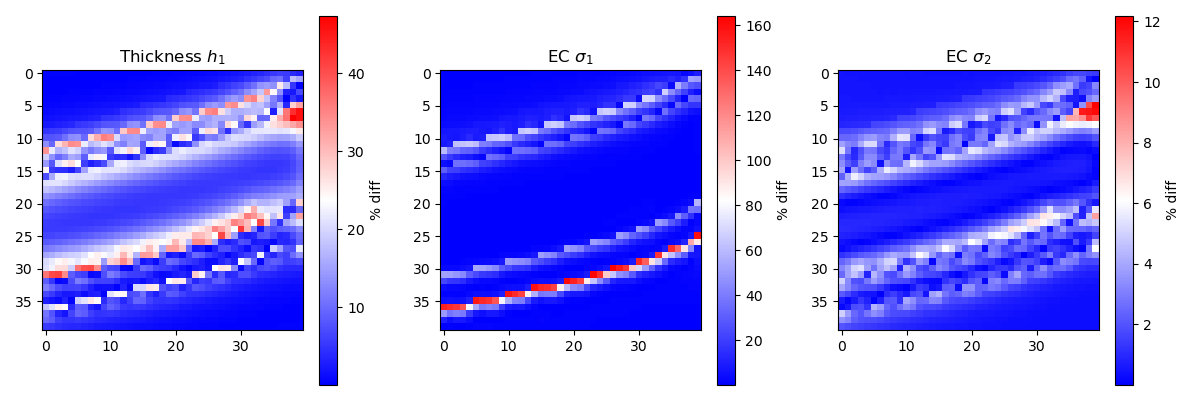

In [14]:
fig, ax = plt.subplots(1,3, figsize=(12,4))

c1 = ax[0].imshow(np.abs((model_true[:,:,0].T-m[:,:,0])/model_true[:,:,0].T)*100, cmap='bwr')
fig.colorbar(c1, ax=ax[0], label='% diff')
ax[0].set_title('Thickness $h_1$')

c2 = ax[1].imshow(np.abs((model_true[:,:,1].T-m[:,:,1])/model_true[:,:,1].T)*100, cmap='bwr')
fig.colorbar(c2, ax=ax[1], label='% diff')
ax[1].set_title('EC $\sigma_1$')

c3 = ax[2].imshow(np.abs((model_true[:,:,2].T-m[:,:,2])/model_true[:,:,2].T)*100, cmap='bwr')
fig.colorbar(c3, ax=ax[2], label='% diff')
ax[2].set_title('EC $\sigma_2$')

plt.tight_layout()

# Check data fit

In [50]:
# Data in PPT

d_true = (data.copy())*1000
d_inv = (np.array(response).reshape(40,40,18))*1000

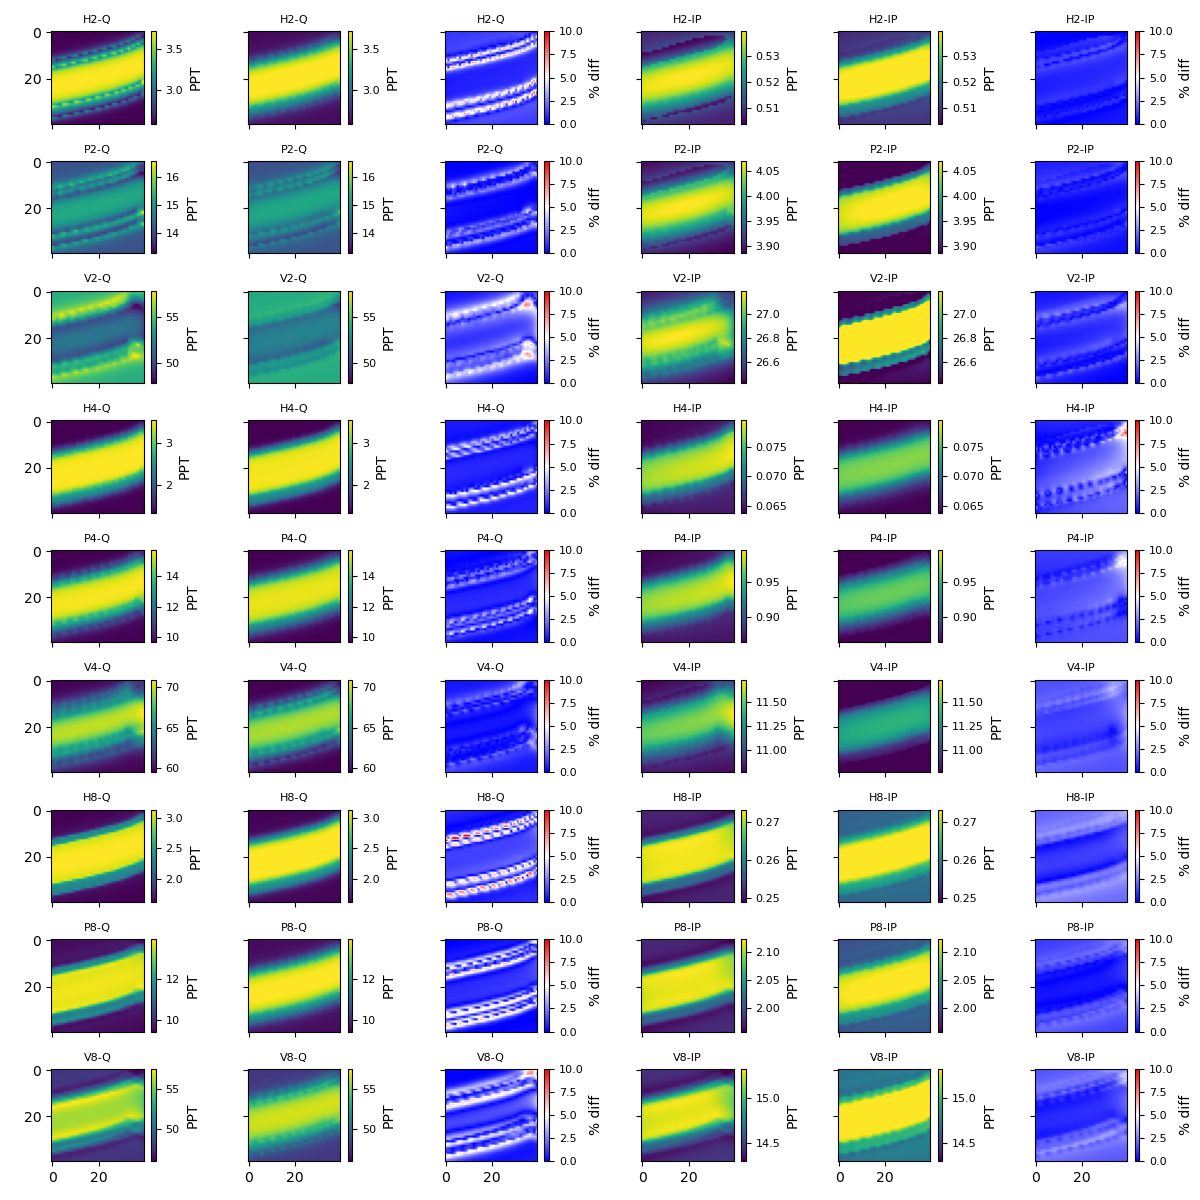

In [52]:
fig, ax = plt.subplots(9,6, figsize=(12,12), sharey=True, sharex=True)

configs = ['H2-Q', 'P2-Q', 'V2-Q', 'H4-Q', 'P4-Q', 'V4-Q', 'H8-Q', 'P8-Q', 'V8-Q', 
           'H2-IP', 'P2-IP', 'V2-IP', 'H4-IP', 'P4-IP', 'V4-IP', 'H8-IP', 'P8-IP', 'V8-IP', ]

fs=8

for i in range(9):
    vmin = min(d_true[:,i])
    vmax = max(d_true[:,i])
    
    c=ax[i,0].imshow(d_true[:,i].reshape(40,40), vmin=vmin, vmax=vmax)
    ax[i,0].set_title(configs[i], fontsize=fs)
    cb = fig.colorbar(c, ax=ax[i,0], label='PPT')
    cb.ax.tick_params(labelsize=fs)

    c=ax[i,1].imshow(d_inv[:,:,i], vmin=vmin, vmax=vmax)
    ax[i,1].set_title(configs[i], fontsize=fs)
    cb =fig.colorbar(c, ax=ax[i,1], label='PPT')
    cb.ax.tick_params(labelsize=fs)

    c=ax[i,2].imshow(np.abs((d_true[:,i].reshape(40,40) - d_inv[:,:,i])/d_true[:,i].reshape(40,40))*100, cmap='bwr', vmin=0, vmax=10)
    ax[i,2].set_title(configs[i], fontsize=fs)
    cb=fig.colorbar(c, ax=ax[i,2], label='% diff')
    cb.ax.tick_params(labelsize=fs)

    vmin = min(d_true[:,i+9])
    vmax = max(d_true[:,i+9])
    
    c=ax[i,3].imshow(d_true[:,i+9].reshape(40,40), vmin=vmin, vmax=vmax)
    ax[i,3].set_title(configs[i+9], fontsize=fs)
    cb=fig.colorbar(c, ax=ax[i,3], label='PPT')
    cb.ax.tick_params(labelsize=fs)

    c=ax[i,4].imshow(d_inv[:,:,i+9], vmin=vmin, vmax=vmax)
    ax[i,4].set_title(configs[i+9], fontsize=fs)
    cb=fig.colorbar(c, ax=ax[i,4], label='PPT')
    cb.ax.tick_params(labelsize=fs)

    c=ax[i,5].imshow(np.abs((d_true[:,i+9].reshape(40,40) - d_inv[:,:,i+9])/d_true[:,i+9].reshape(40,40))*100, cmap='bwr', vmin=0, vmax=10)
    ax[i,5].set_title(configs[i+9], fontsize=fs)
    cb=fig.colorbar(c, ax=ax[i,5], label='% diff')
    cb.ax.tick_params(labelsize=fs)


plt.tight_layout()